In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,MiniBatchKMeans, MeanShift, DBSCAN, AgglomerativeClustering,affinity_propagation
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import matplotlib.cm as cm
from sklearn.impute import KNNImputer
import matplotlib.ticker as ticker
import warnings 
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [2]:
import os
os.chdir(r"C:/Users/EG/Documents/Projects/SHAI/Clustering Project/ALL project")

In [3]:
df = pd.read_csv("CC GENERAL.csv")
dff = df.copy()

# 1-EDA:-

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.shape

(8950, 18)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [7]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
dff.drop("CUST_ID", axis=1, inplace=True)
dff.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 1.1- Checking  missing value

In [10]:
dff.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CASH_ADVANCE_FREQUENCY                0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
PURCHASES_INSTALLMENTS_FREQUENCY      0
BALANCE_FREQUENCY                     0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
TENURE                                0
dtype: int64

In [11]:
dff.loc[dff['MINIMUM_PAYMENTS'].isnull(),"PAYMENTS"]

3         0.000000
45        0.000000
47        0.000000
54      417.016763
55        0.000000
           ...    
8919      0.000000
8929      0.000000
8935      0.000000
8944      0.000000
8946    275.861322
Name: PAYMENTS, Length: 313, dtype: float64

in a credit limit there's one null value so i will drop it

In [12]:
dff.dropna(subset = 'CREDIT_LIMIT', inplace=True)

## 1.2- Checking The outliers 

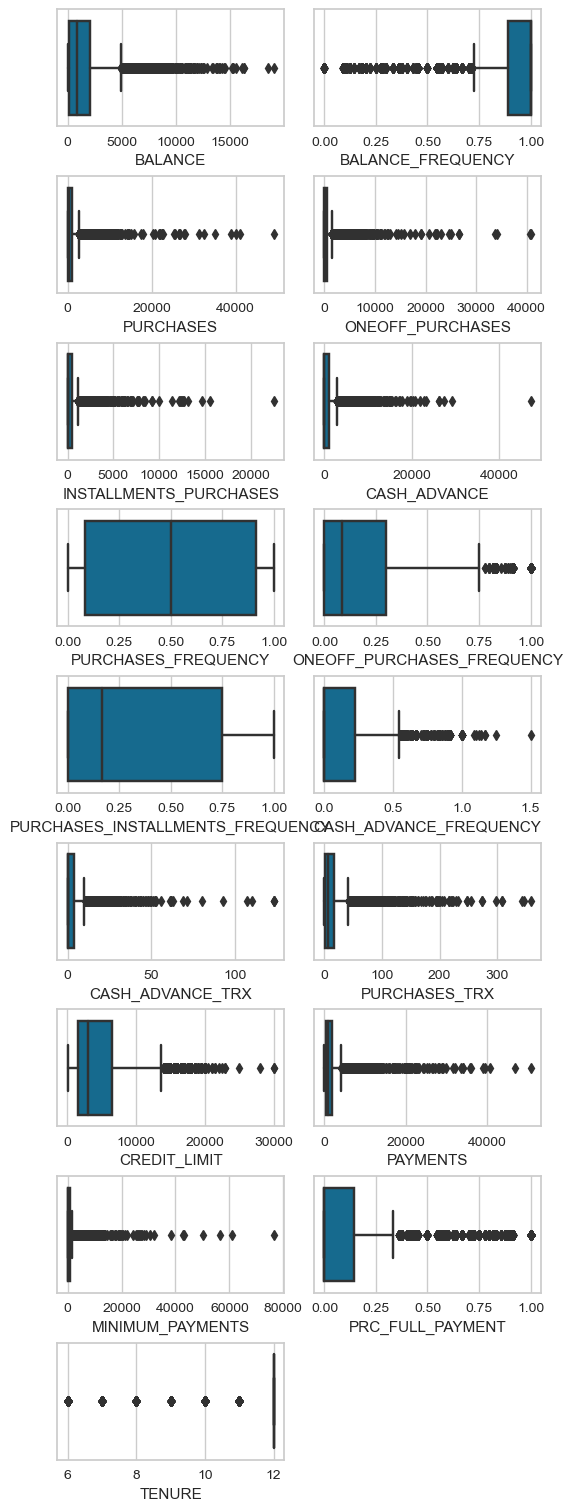

In [13]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(dff.columns):
    if dff[col].dtype != 'object':
        ax = plt.subplot(9, 2, i+1)
        sns.boxplot(dff[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

# 2-Preprocessing:
## 2.1- Imputing missing values and outliers

In [14]:
data = dff.fillna(0)
data.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## 2.2- Scaling The data

#### Data Distribution

In [15]:
scaled = data.copy()

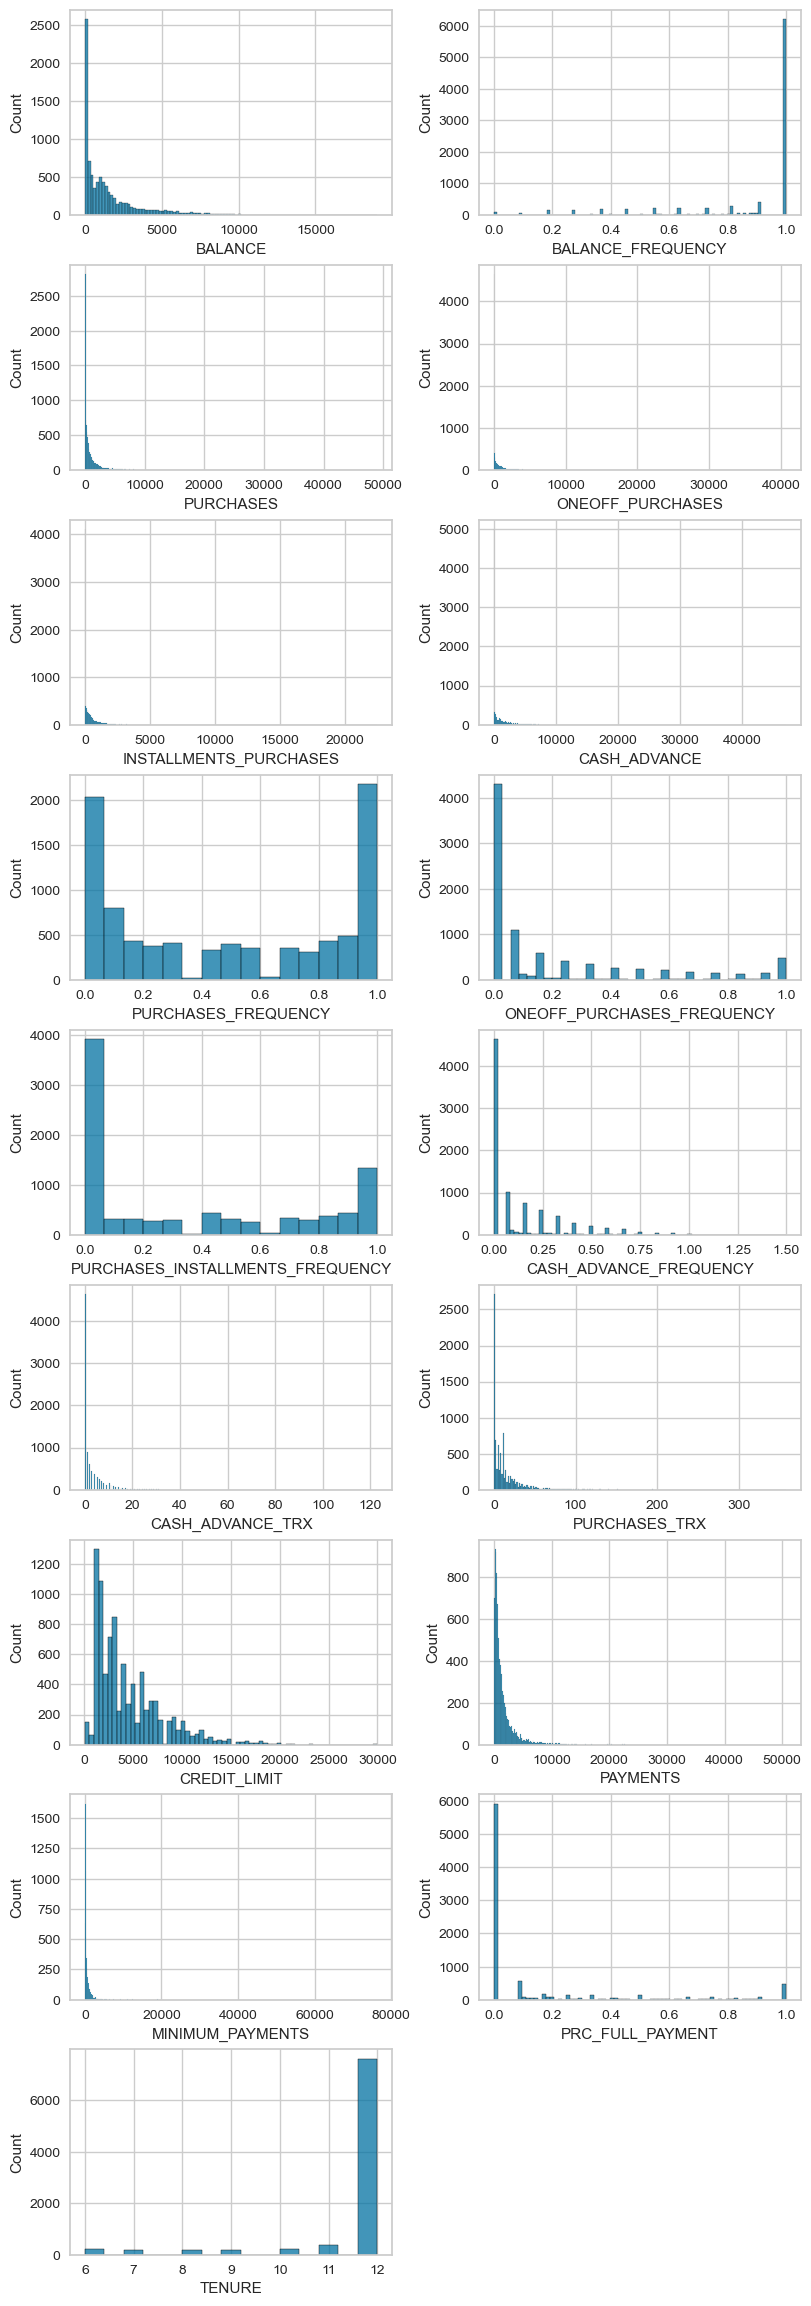

In [16]:
plt.figure(figsize=(8,25), constrained_layout = True)
for  i,col in enumerate(scaled.columns):
    plt.subplot(10,2,i+1)
    sns.histplot(scaled[col])
        
plt.show()

Most of the data is right skewed

### 2.2.1- Standard scaler

In [17]:
SS = StandardScaler()
std_scaled = SS.fit_transform(scaled)
std_scaled = pd.DataFrame(std_scaled, columns=data.columns)
std_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.732054,-0.249881,-0.424934,-0.356957,-0.349114,-0.466805,-0.806649,-0.678716,-0.707409,-0.675294,-0.476083,-0.511381,-0.960380,-0.529026,-0.297334,-0.525588,0.360541
1,0.786858,0.134049,-0.469584,-0.356957,-0.454607,2.605438,-1.221928,-0.678716,-0.917090,0.573949,0.110032,-0.591841,0.688601,0.818546,0.101998,0.234159,0.360541
2,0.447041,0.517980,-0.107716,0.108843,-0.454607,-0.466805,1.269742,2.673295,-0.917090,-0.675294,-0.476083,-0.109082,0.826016,-0.383857,-0.088524,-0.525588,0.360541
3,0.049015,-1.017743,0.231995,0.546123,-0.454607,-0.368678,-1.014290,-0.399383,-0.917090,-0.258882,-0.329554,-0.551611,0.826016,-0.598733,-0.357057,-0.525588,0.360541
4,-0.358849,0.517980,-0.462095,-0.347317,-0.454607,-0.466805,-1.014290,-0.399383,-0.917090,-0.675294,-0.476083,-0.551611,-0.905414,-0.364421,-0.252265,-0.525588,0.360541


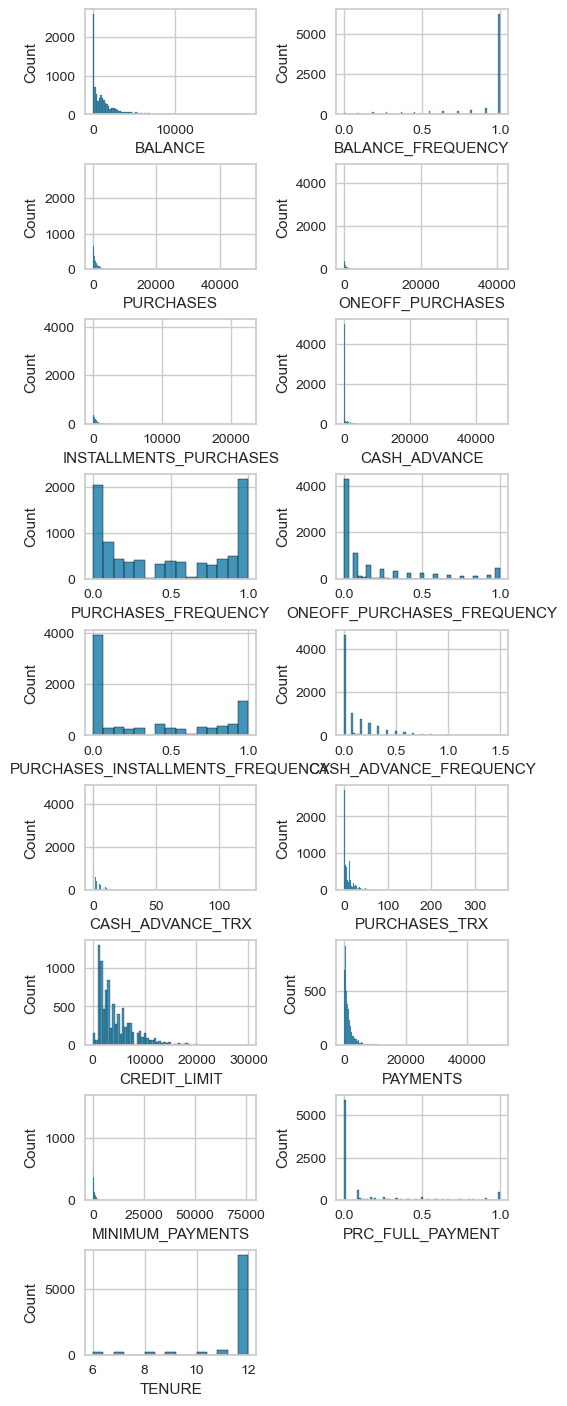

In [18]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(std_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

The data is still little skewed

### 2.2.2-Minmax Scaler

In [19]:
MMS = MinMaxScaler()
mms_scaled = MMS.fit_transform(scaled)
mms_scaled = pd.DataFrame(mms_scaled, columns=data.columns)

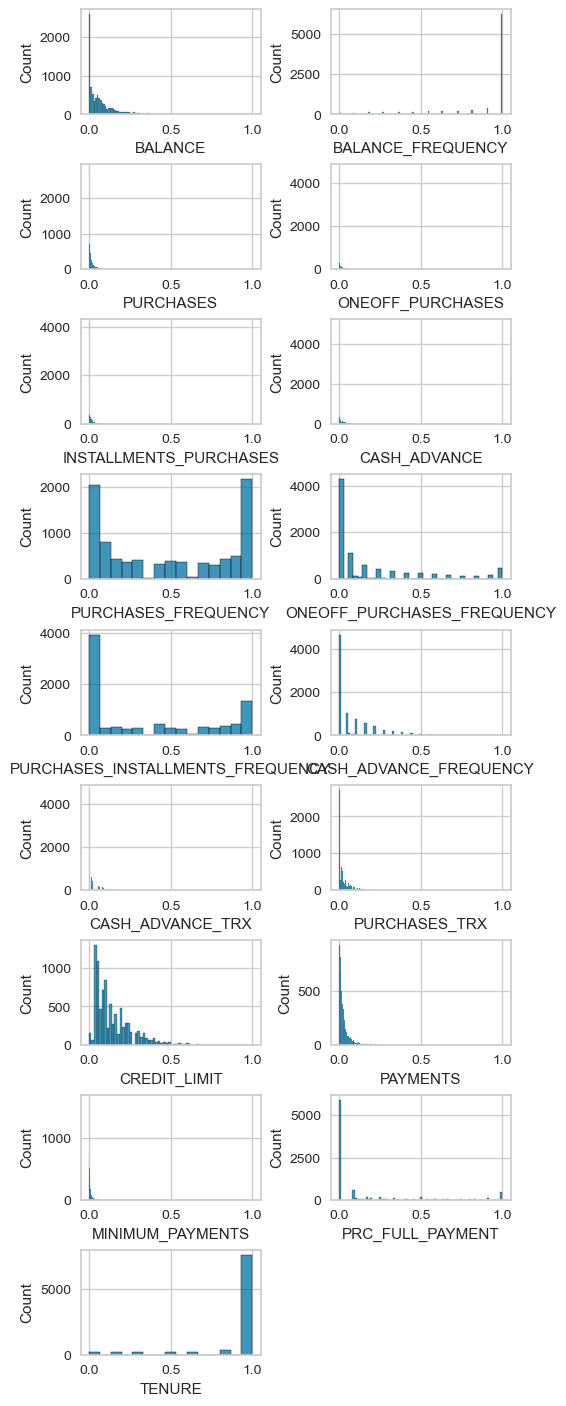

In [20]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(mms_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(mms_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

also after minmax scaler the data is still little right skewed

### 2.2.3- Robust scaler

In [21]:
RS = RobustScaler()
robust_scaled = RS.fit_transform(scaled)
robust_scaled = pd.DataFrame(robust_scaled, columns=data.columns)

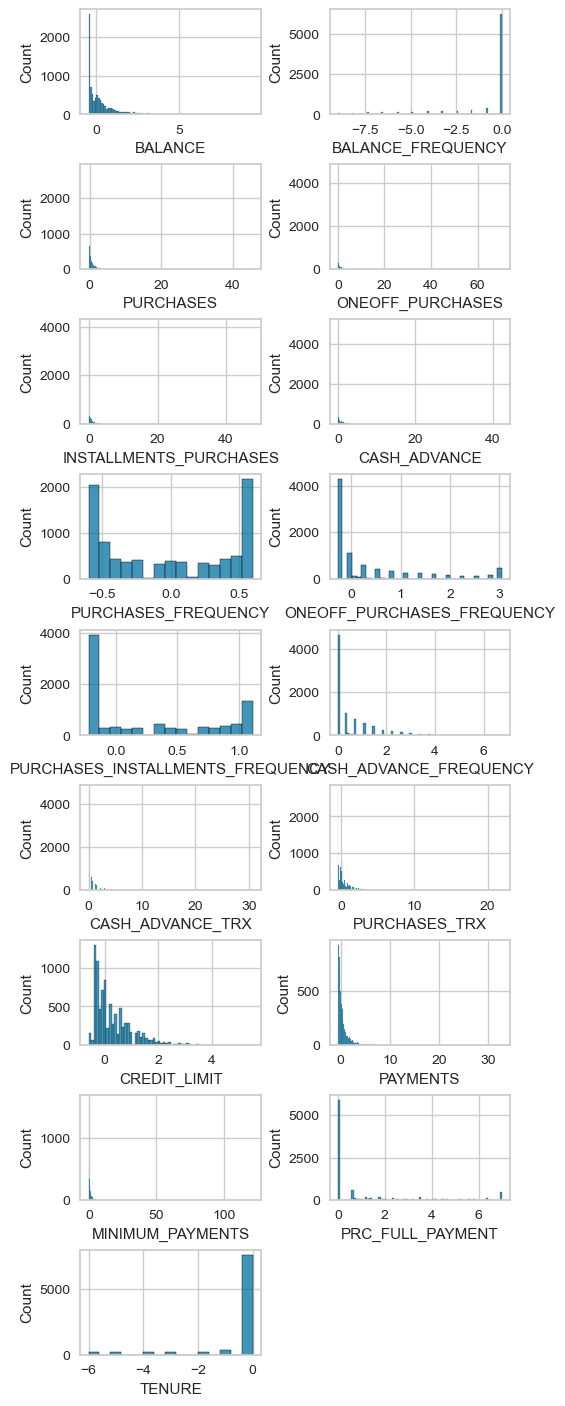

In [22]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(robust_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(robust_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.4- log scaler for right skewed  and quantile transformer for left skewed

In [23]:
log_scaled = scaled.copy()
QT = QuantileTransformer(output_distribution='normal')
for col in scaled.columns:
    if col in ["BALANCE_FREQUENCY","PURCHASES_FREQUENCY"]:
        log_scaled[[col]] = QT.fit_transform(log_scaled[[col]])
    else:
        log_scaled[col] = np.log(1 + log_scaled[col])
log_scaled.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000
mean,6.161994,3.235600,4.900195,3.204632,3.352778,3.318872,0.068124,0.158717,0.270102,0.113508,0.817584,1.894942,8.094835,6.625023,5.715417,0.117743,2.519744
std,2.013132,2.992096,2.916575,3.246370,3.082942,3.566440,3.581785,0.216678,0.281853,0.156724,1.009372,1.373787,0.819674,1.591197,1.597118,0.211625,0.130233
min,0.000000,-5.199338,0.000000,0.000000,0.000000,0.000000,-5.199338,0.000000,0.000000,0.000000,0.000000,0.000000,3.931826,0.000000,0.000000,0.000000,1.945910
25%,4.862644,-0.672129,3.708682,0.000000,0.000000,0.000000,-0.625670,0.000000,0.000000,0.000000,0.000000,0.693147,7.378384,5.951379,5.100046,0.000000,2.564949
50%,6.773858,5.199338,5.892997,3.663562,4.499810,0.000000,0.037646,0.080042,0.154151,0.000000,0.000000,2.079442,8.006701,6.754677,5.672247,0.000000,2.564949
75%,7.628213,5.199338,7.013169,6.361009,6.151988,7.016492,0.625670,0.262364,0.559616,0.200671,1.609438,2.890372,8.779711,7.550808,6.671680,0.133531,2.564949
max,9.854515,5.199338,10.800403,10.615512,10.021315,10.760839,5.199338,0.693147,0.693147,0.916291,4.820282,5.883322,10.308986,10.834125,11.243832,0.693147,2.564949


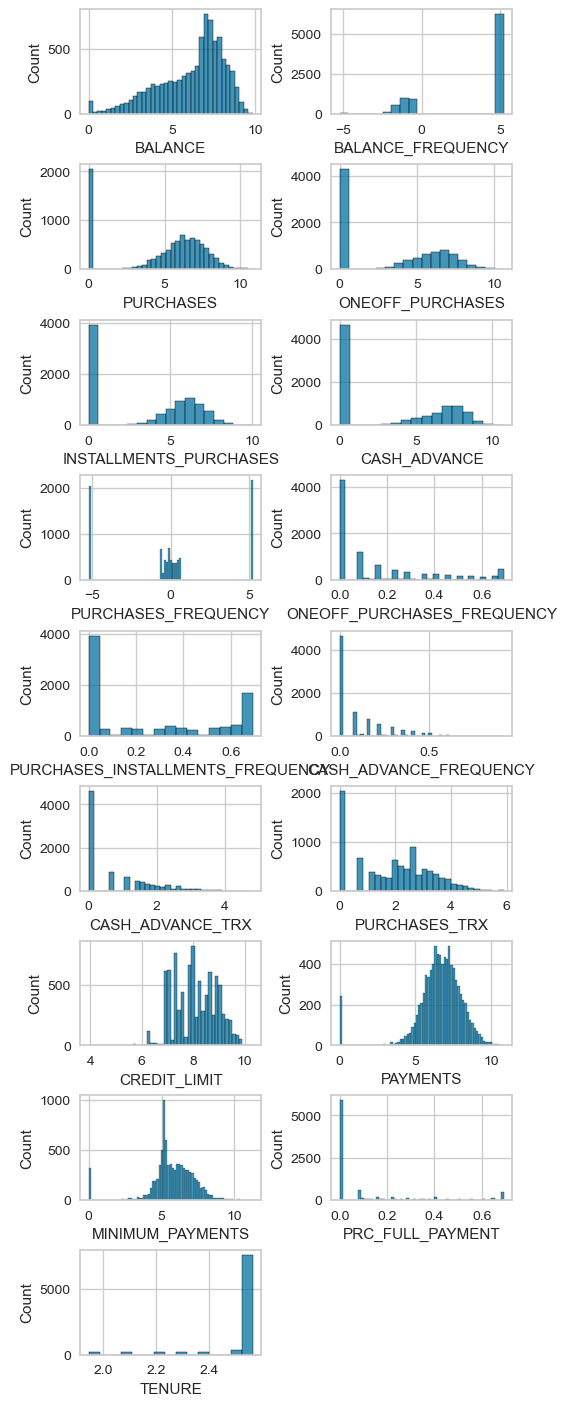

In [24]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(log_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(log_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.5- Power Transformer

In [25]:
PS = PowerTransformer()
PS.fit(scaled)
ps_scaled = PS.transform(scaled)
ps_scaled = pd.DataFrame(ps_scaled, columns=data.columns)

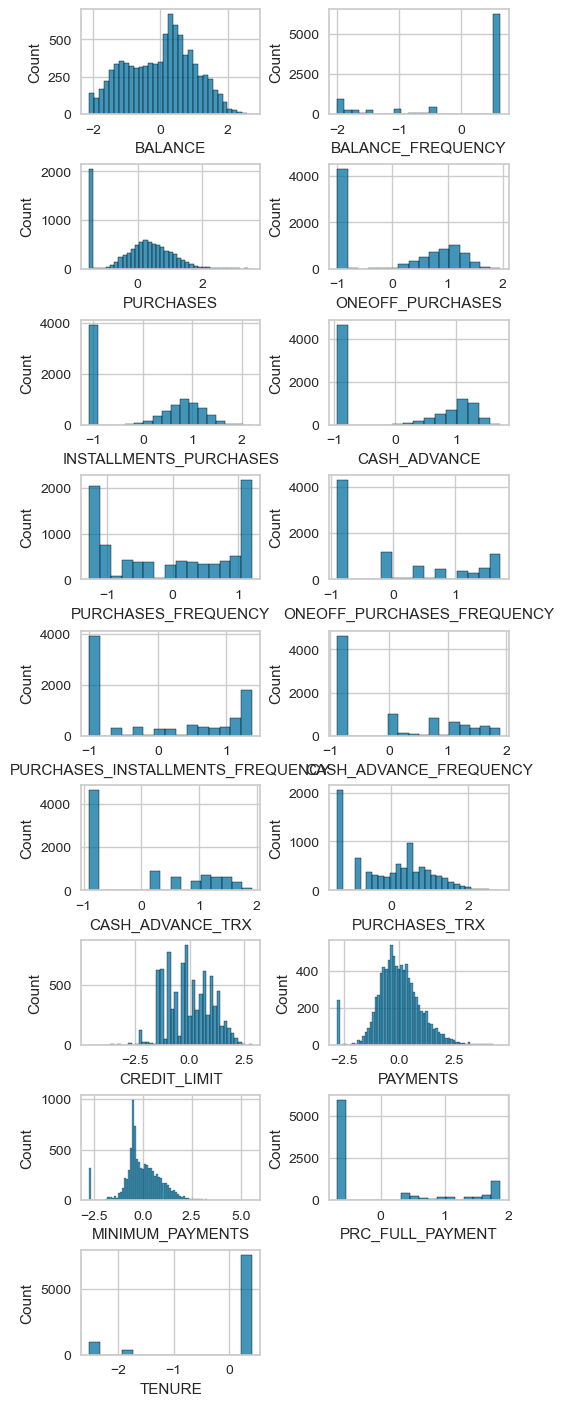

In [26]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(ps_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(ps_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

### 2.2.6- Quantile Transformer

In [27]:
QT = QuantileTransformer(output_distribution="normal")
QT.fit(scaled)
QT_scaled = QT.transform(scaled)
QT_scaled = pd.DataFrame(QT_scaled, columns=data.columns)

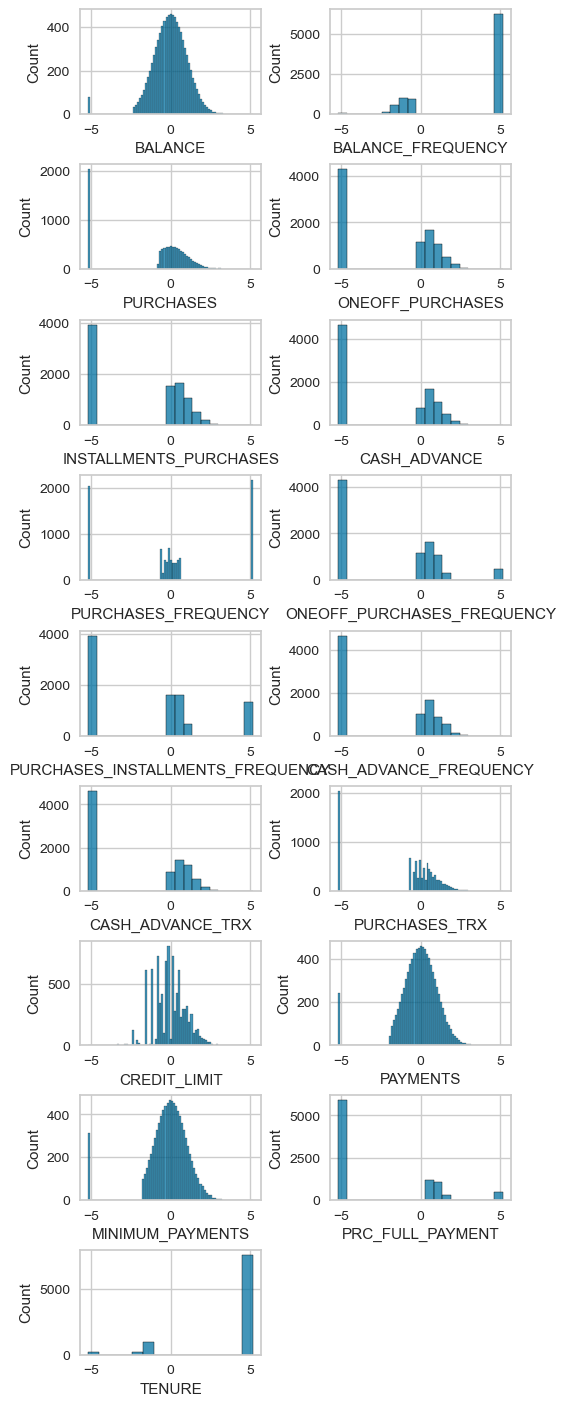

In [28]:
plt.figure(figsize=(5,15), constrained_layout = True)
for i, col in enumerate(ps_scaled.columns):
        ax = plt.subplot(10, 2, i+1)
        sns.histplot(QT_scaled[col], ax=ax)
        plt.xlabel(col)
        
plt.show()

# 3- Dimensional reduction using pca

In [29]:
PCA_data = std_scaled.copy()

<AxesSubplot:>

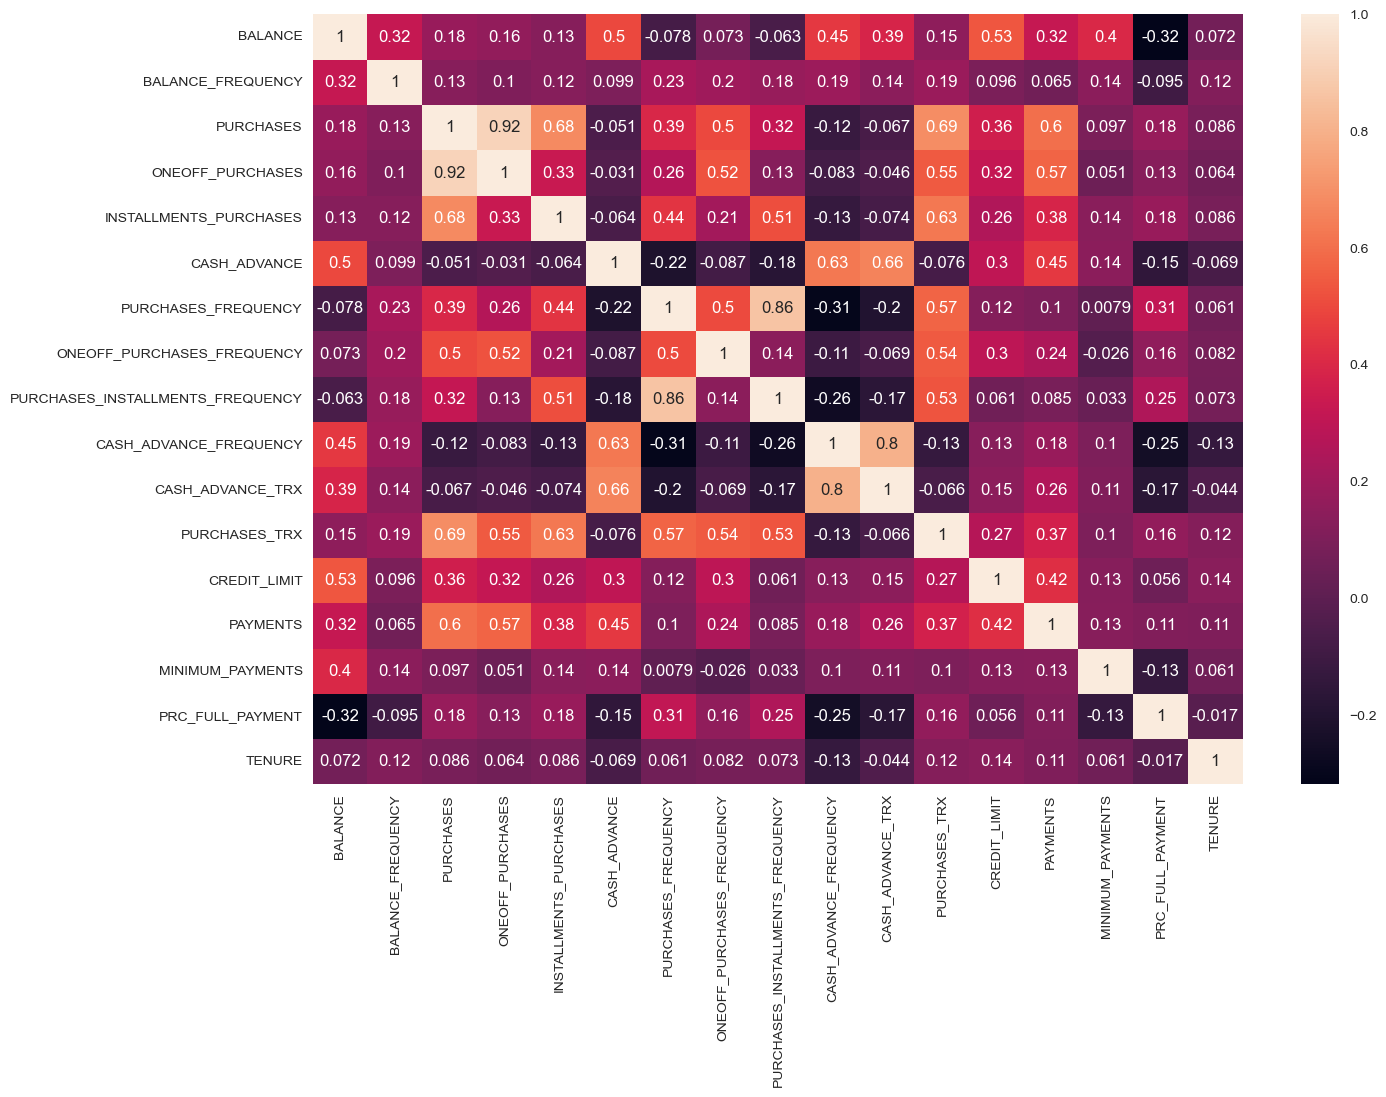

In [30]:
plt.figure(figsize=(15,10))
sns.heatmap(PCA_data.corr(), annot=True)

#### PCA vs Kernel PCA

In [31]:
X_Pca = PCA(n_components=2).fit_transform(PCA_data)
X_KPca = KernelPCA(n_components=2, kernel='rbf').fit_transform(PCA_data)

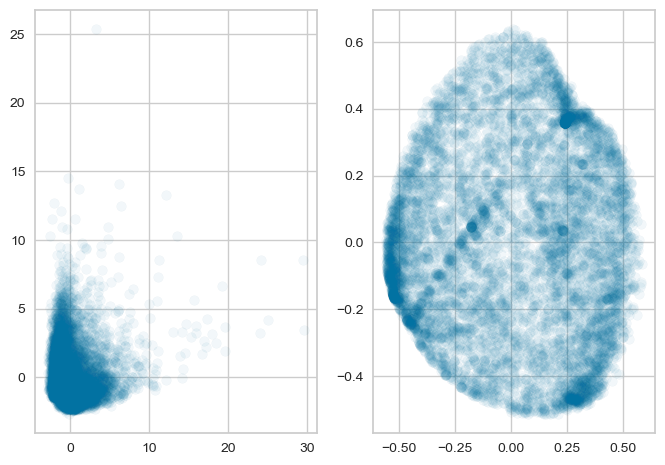

In [32]:
plt.subplot(1,2,1)
plt.scatter(X_Pca[:,0], X_Pca[:,1], alpha=.05)

plt.subplot(1,2,2)
plt.scatter(X_KPca[:,0], X_KPca[:,1], alpha=.05)

### 3.1 PCA

In [33]:
X_pca = PCA(n_components=5).fit_transform(PCA_data)
X_pca.shape

(8949, 5)

### 3.2 Kernel PCA

In [34]:
Kpca = KernelPCA(n_components=9,kernel='rbf', gamma=0.03)
X_reduced = Kpca.fit_transform(PCA_data)

In [35]:
X_reduced.shape

(8949, 9)

In [36]:
Pca_data = pd.DataFrame(X_reduced, columns= [f"PCA{i}" for i in range(X_reduced.shape[1])])
Pca_data.head()

,PCA0,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8
0,-0.299933,-0.297136,0.055697,0.052283,0.021185,-0.035514,-0.030820,0.143882,0.052990
1,-0.279371,0.356985,-0.051872,-0.048816,-0.220531,0.084424,0.095210,-0.090379,-0.011551
2,0.210156,0.056138,-0.166626,0.460112,0.151530,0.008070,0.040065,-0.230424,0.201316
3,-0.270330,-0.078396,0.103161,0.232555,-0.127915,-0.103565,0.117157,-0.070456,-0.107651
4,-0.327306,-0.234402,-0.076300,0.095435,0.069651,0.047885,0.029710,0.187055,0.073598


In [37]:
# pca.explained_variance_ratio_.sum()*100

# 4-Modelling:-

In [38]:
X =X_pca.copy()

In [39]:
def silhouette_plot(model, X, keyword, keyword_range,X_TSNE, plot=True, **kwargs):
    """
    Evaluate Silhouette score for a model with a range of values for keyword argument.
    
    Input:
    ------
    model -- model to be scored
    X -- features
    keyword -- model keyword to use for evaluation
    keyword_range -- range of values for keyword
    plot -- boolean if set to true, then Silhouette score will be plotted
    kwargs -- the rest of the model kwargs (optional)
    """

    for kw_value in keyword_range:
        if plot:
            fig, (ax,ax1) = plt.subplots(1,2)
            fig.set_size_inches(14, 7)

            # The silhouette coefficient can range from -1, 1 but in this example all
            # lie within [-0.1, 1]
            ax.set_xlim([-0.1, 1])
            # The (kw_value+1)*10 is for inserting blank space between silhouette
            # plots of individual clusters, to demarcate them clearly.
            ax.set_ylim([0, len(X) + (kw_value + 1) * 10])

        # Initialize the clusterer with kw_value value and a random generator
        # seed of 10 for reproducibility.
        clusterer = model(**{keyword: kw_value}, **kwargs)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            f"For {keyword} =",
            kw_value,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        if plot:
            # Compute the silhouette scores for each sample
            sample_silhouette_values = silhouette_samples(X, cluster_labels)

            y_lower = 10
            for i in range(len(set(cluster_labels))):
                # Aggregate the silhouette scores for samples belonging to
                # cluster i, and sort them
                ith_cluster_silhouette_values = sample_silhouette_values[
                    cluster_labels == i
                ]

                ith_cluster_silhouette_values.sort()

                size_cluster_i = ith_cluster_silhouette_values.shape[0]
                y_upper = y_lower + size_cluster_i

                ax.fill_betweenx(
                    np.arange(y_lower, y_upper),
                    0,
                    ith_cluster_silhouette_values,
                    alpha=0.7,
                )

                # Label the silhouette plots with their cluster numbers at the middle
                ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

                # Compute the new y_lower for next plot
                y_lower = y_upper + 10  # 10 for the 0 samples

            ax.set_title(f"The silhouette plot for {kw_value} {keyword}.")
            ax.set_xlabel("The silhouette coefficient values")
            ax.set_ylabel("Cluster label")

            # The vertical line for average silhouette score of all the values
            ax.axvline(x=silhouette_avg, color="red", linestyle="--")

            ax.set_yticks([])  # Clear the yaxis labels / ticks
            ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
            
            sns.scatterplot(
            x = X_TSNE[:, 0],
            y = X_TSNE[:, 1],
            hue=cluster_labels,
            palette=sns.color_palette("colorblind", len(set(cluster_labels))),
            alpha=0.3,
            legend="full",
            ax = ax1
            )
            ax1.set_title("The visualization of the clustered data.")
            ax1.set_xlabel("Feature space for the 1st feature")
            ax1.set_ylabel("Feature space for the 2nd feature")

            plt.suptitle(
            f"Silhouette analysis for {model.__name__} clustering on sample data with {keyword} = {kw_value}",
            fontsize=14,
            fontweight="bold",
            )


    if plot:
        plt.show()

In [40]:
X_TSNE = TSNE(n_components=2,
                   perplexity=3,
                   init='pca', 
                   method='barnes_hut', 
                   n_jobs=-1, 
                   random_state=42).fit_transform(X)

## 4.1 KMeans:-

### Choosing number of clusters :-
#### using ELBOW method

In [41]:
inertia_scores = []
silhouette_scores = []
for i in range(2,10):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(X)
    inertia_scores.append(Kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, Kmeans.labels_))

In [42]:
silhouette_scores

[0.28118081138175754,
 0.31562886276482854,
 0.28751966135001905,
 0.28489960016435584,
 0.2713889483048578,
 0.27641498415041854,
 0.27112897675686887,
 0.2784811235316261]

In [43]:
np.argmax(silhouette_scores) + 2

3

###### ElBowVizualizer:-

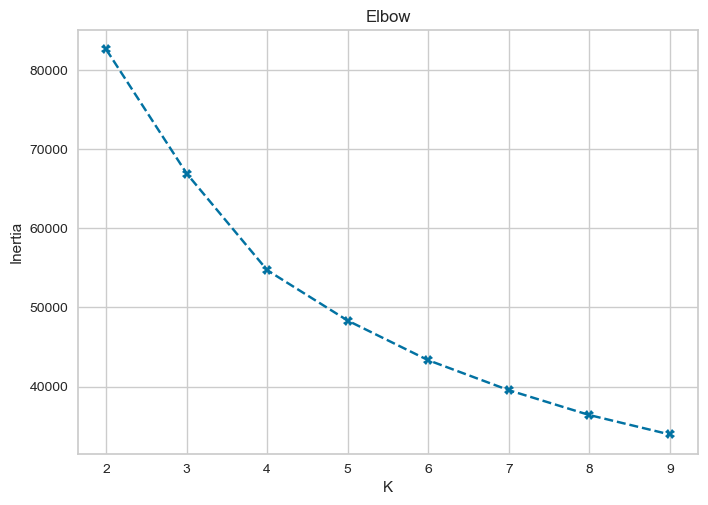

In [44]:
plt.plot(range(2,10), inertia_scores, "--X")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow")
plt.show()

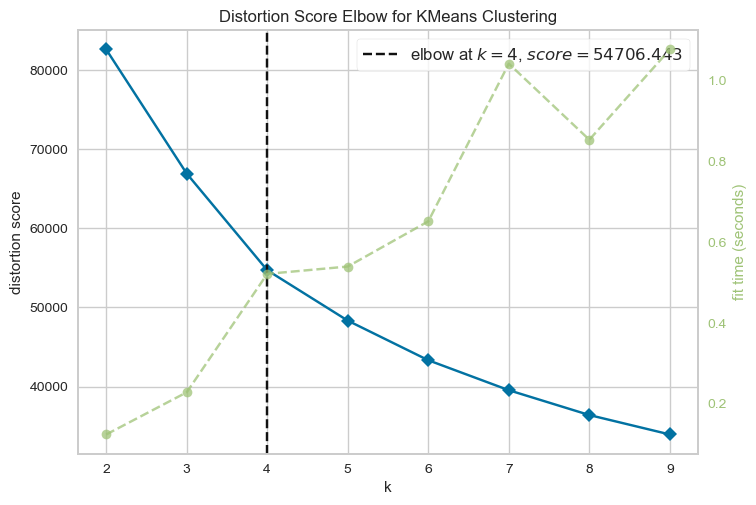

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [45]:
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,10))

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

####  Vizualization for each cluster

For n_clusters = 4 The average silhouette_score is : 0.2880373724257774
For n_clusters = 5 The average silhouette_score is : 0.28464119569950713
For n_clusters = 6 The average silhouette_score is : 0.27150079428626495
For n_clusters = 7 The average silhouette_score is : 0.27641498415041854


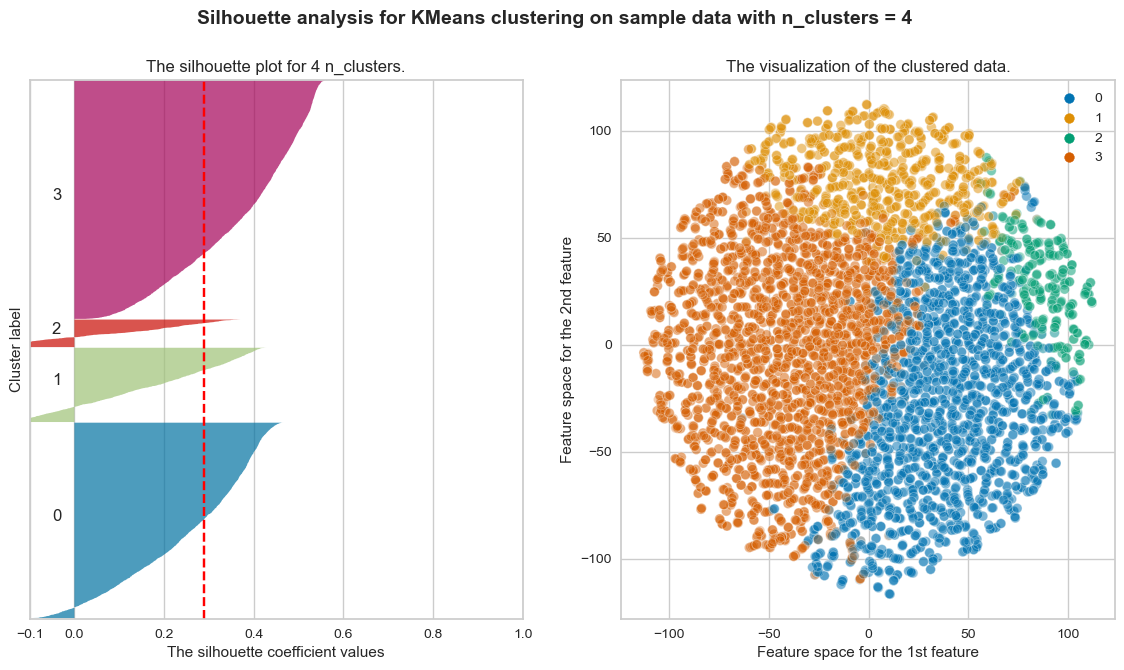

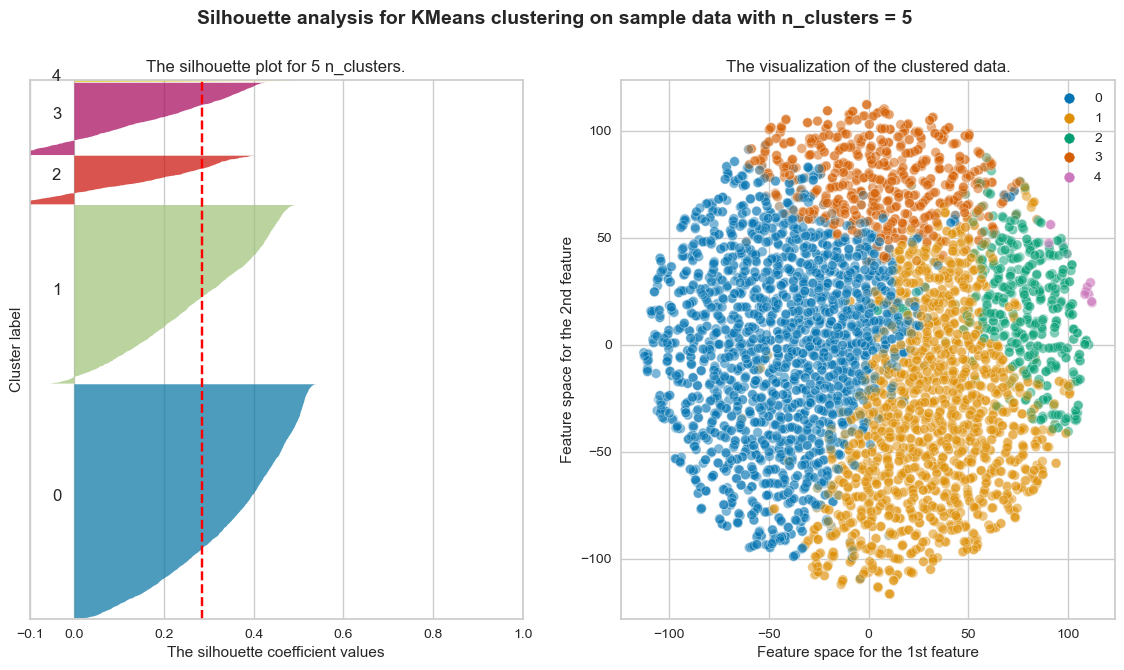

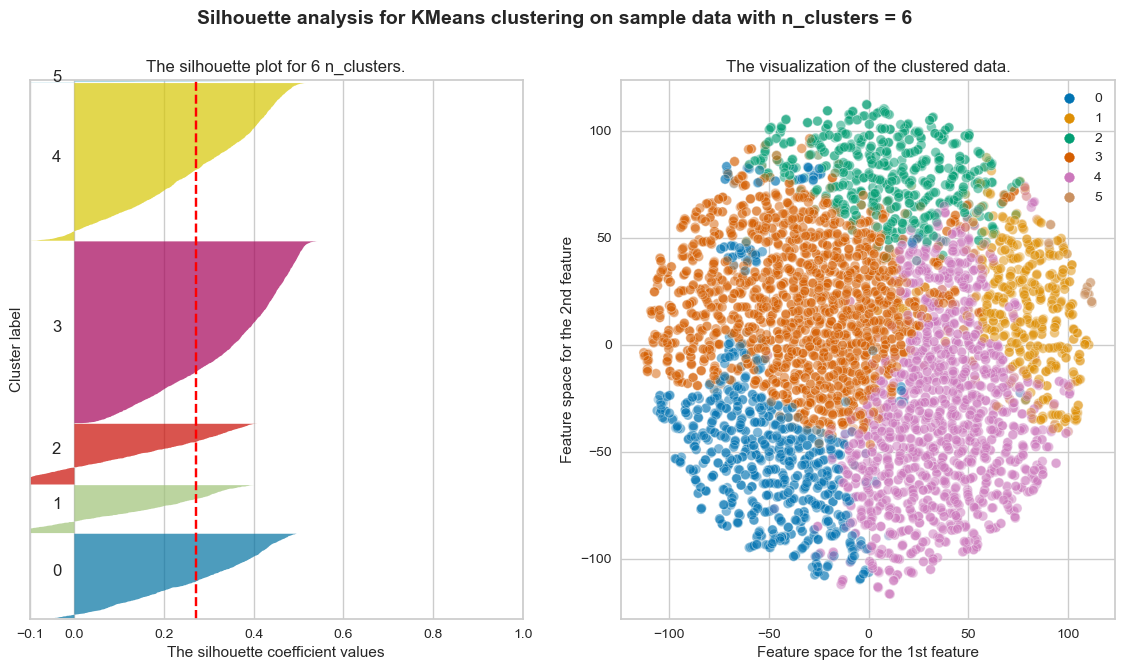

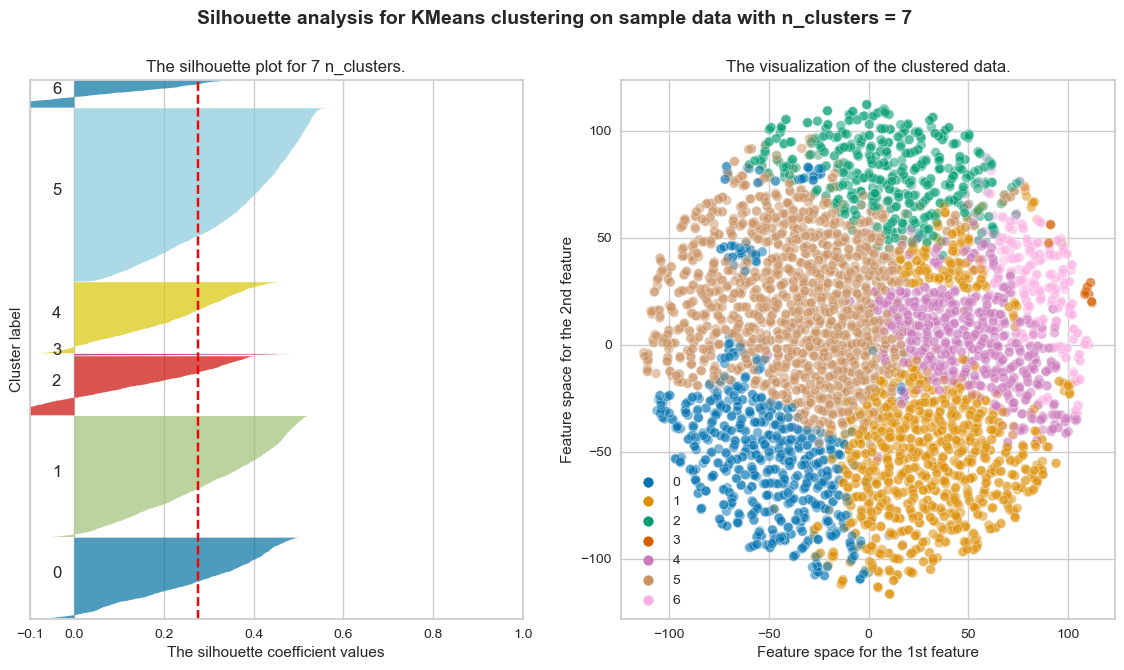

In [46]:
silhouette_plot(KMeans, X, "n_clusters", range(4,8), X_TSNE)

#### Training the model

In [48]:
KMeans_model= KMeans(4, random_state = 42).fit(X)

## 4.2 AgglomerativeClustering

### choosing number of clusters:
#### Using ELBOW method

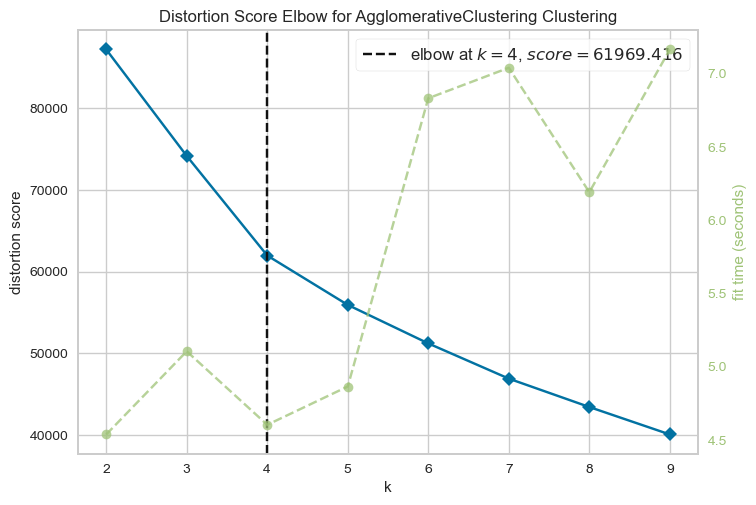

<AxesSubplot:title={'center':'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [49]:
visualizer = KElbowVisualizer(AgglomerativeClustering(), k=(2,10))

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()  

#### Vizualization of each cluster

For n_clusters = 4 The average silhouette_score is : 0.2405362970588547
For n_clusters = 5 The average silhouette_score is : 0.24182003481783915
For n_clusters = 6 The average silhouette_score is : 0.22058481920269832
For n_clusters = 7 The average silhouette_score is : 0.22758196187385013


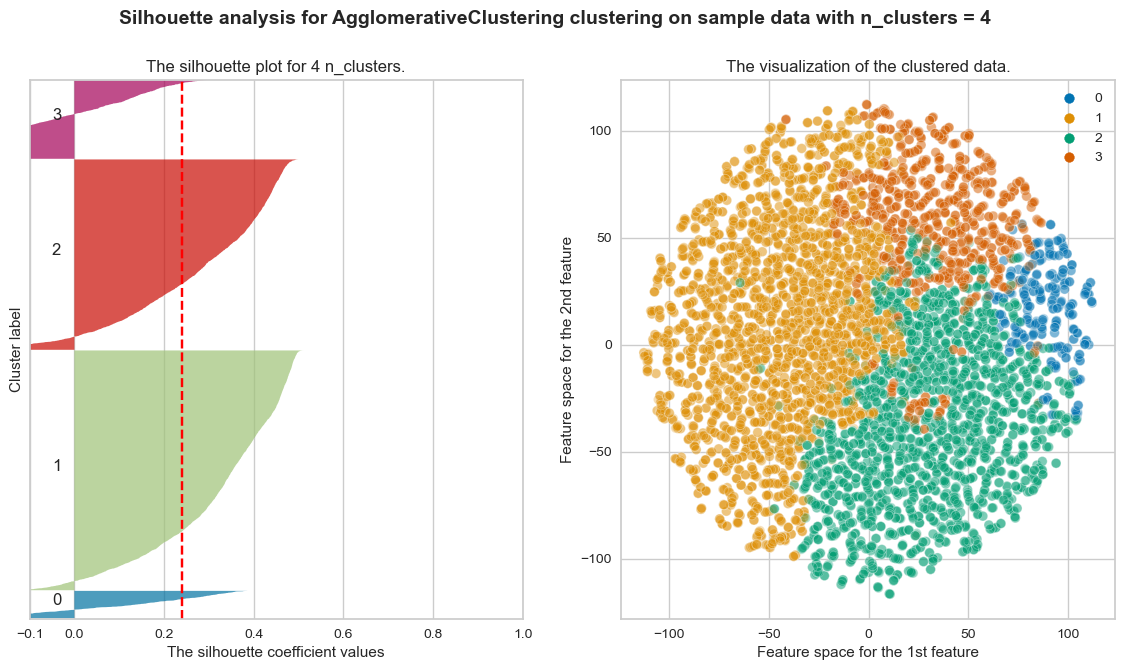

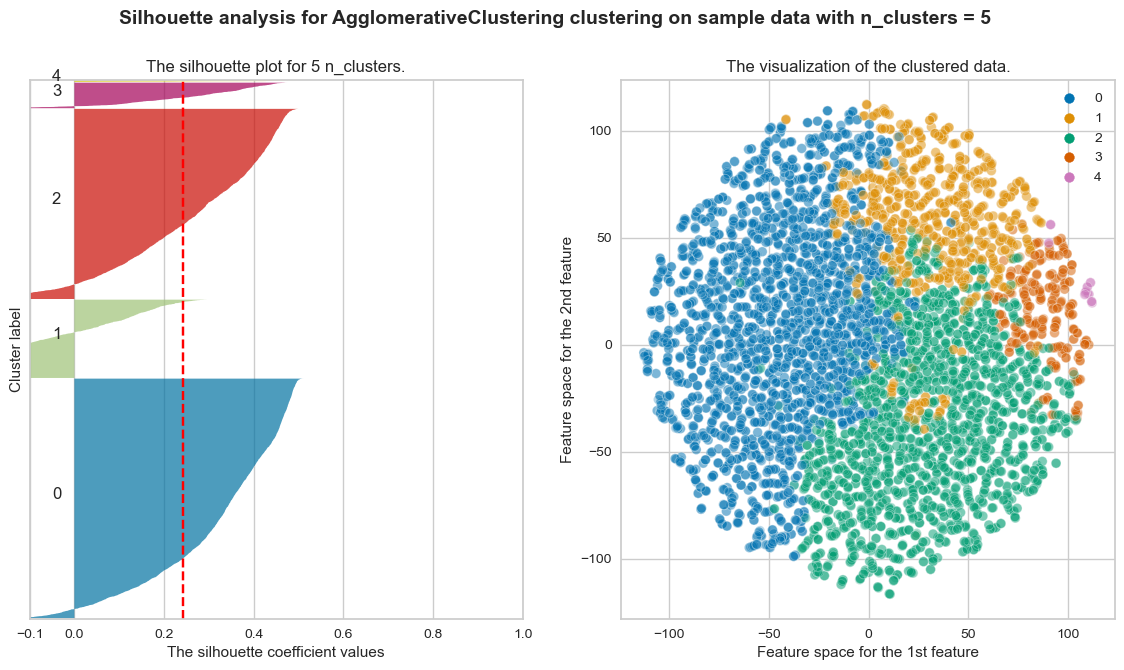

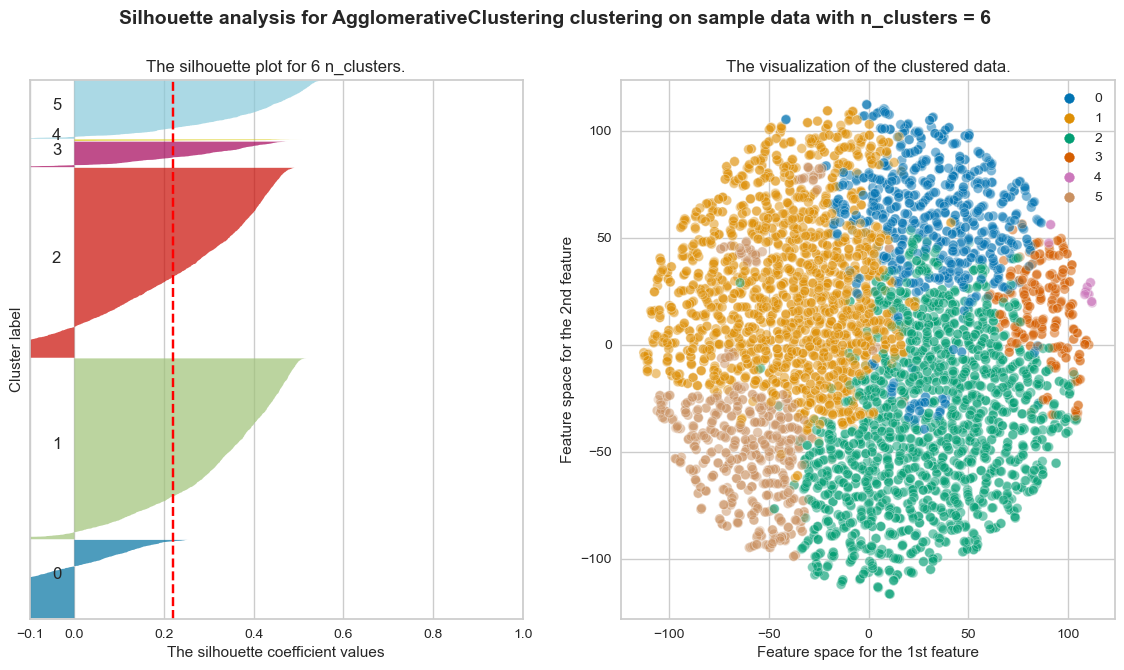

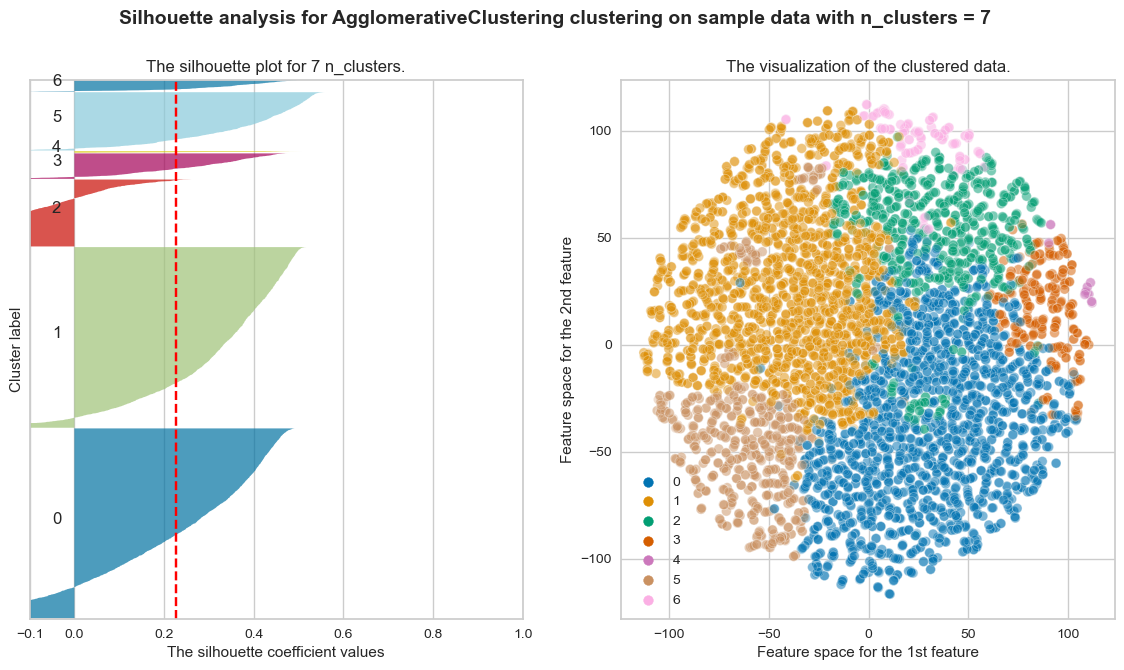

In [50]:
silhouette_plot(AgglomerativeClustering, X, "n_clusters", range(4,8), X_TSNE)

#### Training The model:-

In [51]:
agglomerative_model = AgglomerativeClustering(n_clusters=5).fit(X)

## 4.3 Gaussian Mixture:

### choosing number of clusters:
#### Vizualization of each cluster

For n_components = 4 The average silhouette_score is : 0.1393623271539433
For n_components = 5 The average silhouette_score is : 0.12881118671960162
For n_components = 6 The average silhouette_score is : 0.08260936907502812
For n_components = 7 The average silhouette_score is : 0.026053202234639774


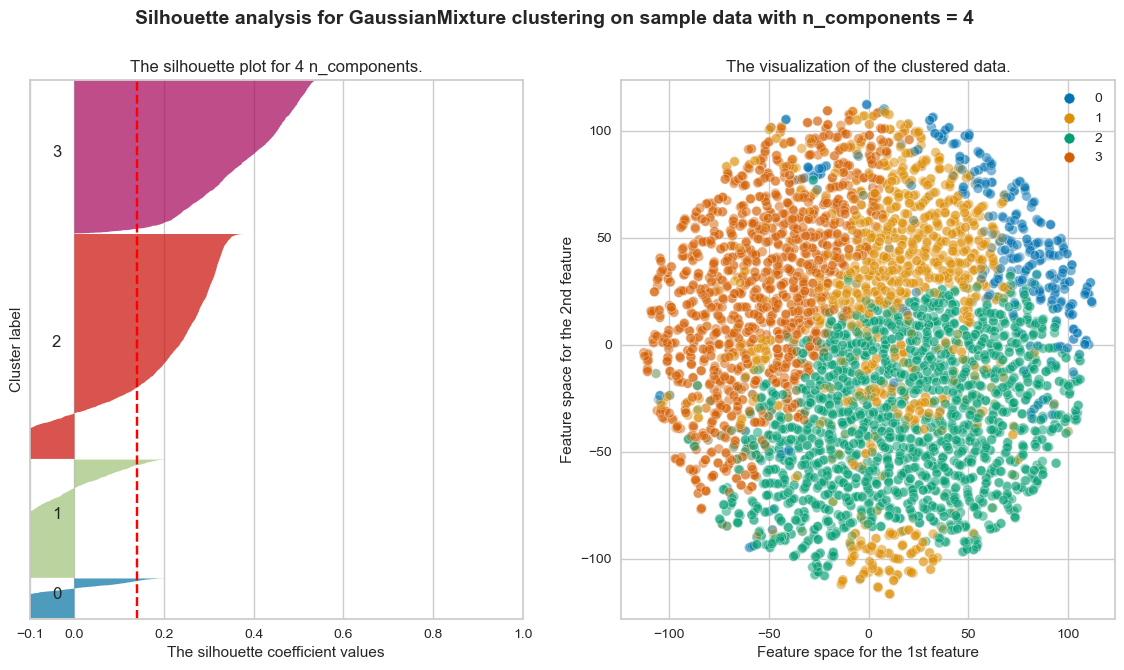

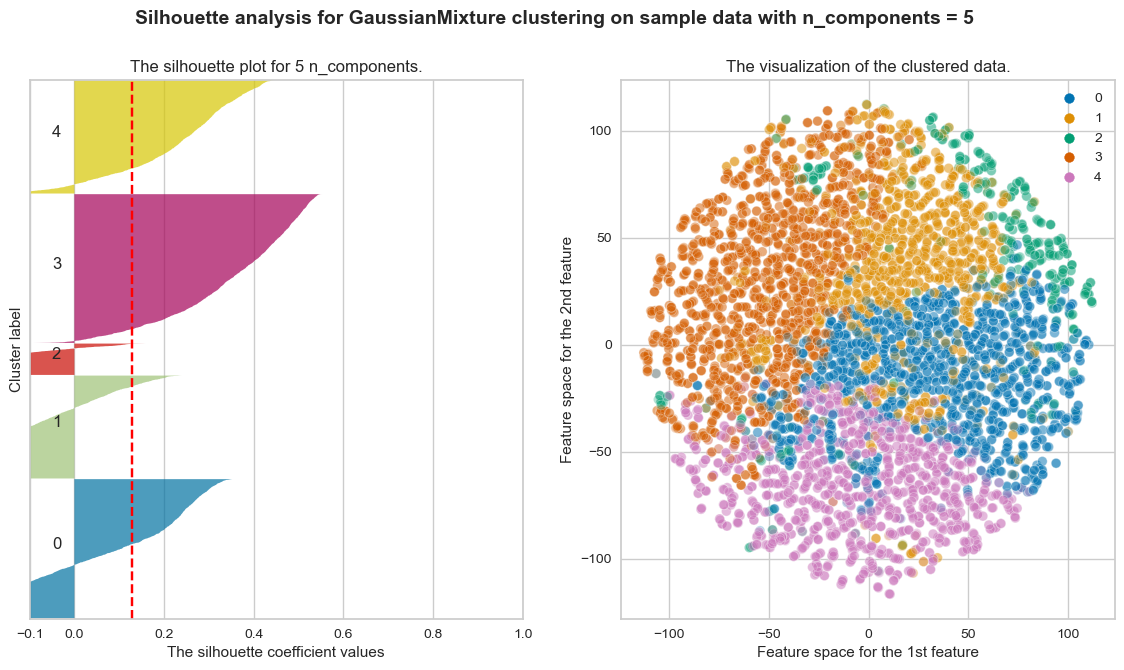

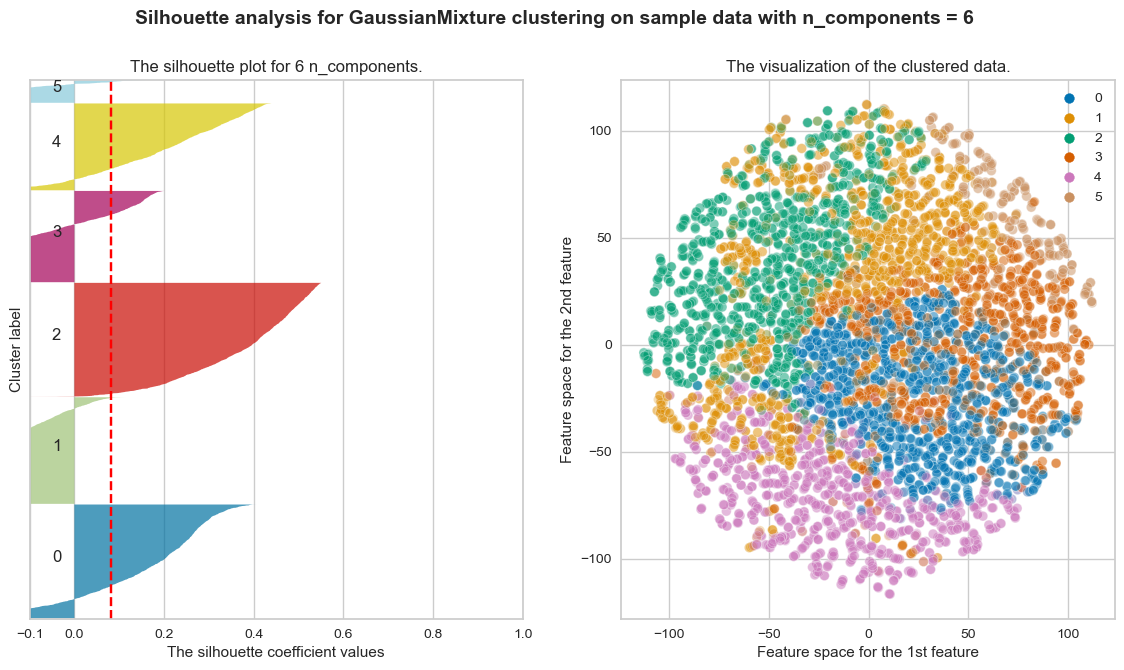

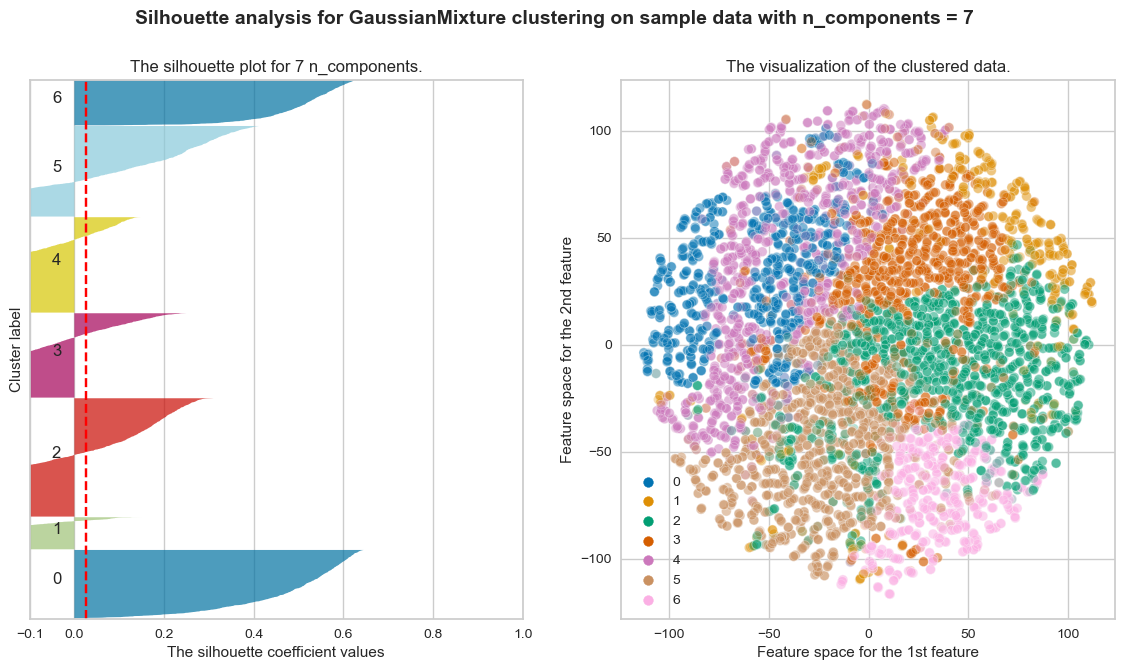

In [52]:
silhouette_plot(GaussianMixture, X, "n_components", range(4,8), X_TSNE)

In [53]:
Gaussian_model = GaussianMixture(n_components=4, random_state=42).fit(X)

## 4.4 Mean shift

### choosing number of clusters:
#### Vizualization of each cluster

In [54]:
# silhouette_plot(MeanShift, X, "bandwidth", [.44,.46,.47,.49,.51,.53,.58], X_TSNE)

### Training The model

In [70]:
Meanshift_model = MeanShift(bandwidth=.49).fit(X)

In [71]:
len(np.unique(Meanshift_model.labels_))

2433

## 4.5 DBSCAN

In [56]:
eps_min = 0.1; eps_max = 13
samples_min = 2; samples_max = 10

In [57]:
db_best_so_far = -1
eps_best_so_far = 0
samples_so_far = 0
i = eps_min
while i <= eps_max :
    for j in range(samples_min, samples_min+1, 1):
        db = DBSCAN(eps = i, min_samples = j).fit(X)
        if len(np.unique(db.labels_)) >1:
            
            score = silhouette_score(X, db.labels_)
        if score > db_best_so_far:
            db_best_so_far = score
            eps_best_so_far = i
            samples_so_far = j
    i+=0.1
db_best_so_far

0.8549803001311534

In [58]:
print(f"The best score for DBSCAN = {db_best_so_far} with eps = {eps_best_so_far} and min_sample = {samples_so_far}")

The best score for DBSCAN = 0.8549803001311534 with eps = 7.499999999999989 and min_sample = 2


### Training and vizualization

In [59]:
db_model = DBSCAN(eps=eps_best_so_far, min_samples=samples_so_far).fit(X)

In [60]:
print(f"Numbers of k = {len(np.unique(db_model.labels_))}")

Numbers of k = 2


<AxesSubplot:>

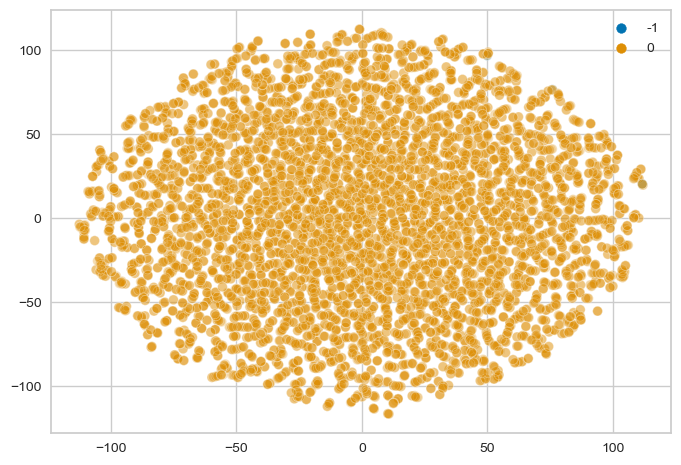

In [72]:
sns.scatterplot(
            x = X_TSNE[:, 0],
            y = X_TSNE[:, 1],
            hue=db_model.labels_,
            palette=sns.color_palette("colorblind", len(set(db_model.labels_))),
            alpha=0.3,
            legend="full",
            )

## 5-Comparing silhouette and Davies-Bouldin Index for the models
### 5.1 Silhouette scores:

In [66]:
silhouette_scores = []

for model in [KMeans_model, agglomerative_model, Gaussian_model, db_model]:
    try: 
        score = silhouette_score(X, model.labels_)
    except:
        score = silhouette_score(X, model.predict(X))
    
        
    silhouette_scores.append((model.__class__.__name__, score))

In [67]:
sorted(silhouette_scores, key=lambda x: -x[1])

[('DBSCAN', 0.8549803001311534),
 ('KMeans', 0.28751966135001905),
 ('AgglomerativeClustering', 0.24182003481783915),
 ('GaussianMixture', 0.13932722829632177)]

### 5.2: Davies-Bouldin Index

In [68]:
DB_scores = []

for model in [KMeans_model, agglomerative_model, Gaussian_model, db_model]:
    try: 
        score = davies_bouldin_score(X, model.labels_)
    except:
        score = davies_bouldin_score(X, model.predict(X))
        
    DB_scores.append((model.__class__.__name__, score))

In [69]:
sorted(DB_scores, key=lambda x: x[1])

[('KMeans', 1.1808035848830092),
 ('DBSCAN', 1.1877196294028514),
 ('AgglomerativeClustering', 1.2309198409579831),
 ('GaussianMixture', 2.0520067644501205)]

###### will go with DBSCAN